<a href="https://colab.research.google.com/github/RiyaGiyamalani/Riya1/blob/main/DAV1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [9]:
df = pd.read_csv("IMDBNew (1) (2).xls")

In [10]:
df.head(2)

,Rank,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
0,1,2014,121,8.1,757074,333.13,76.0
1,2,2012,124,7.0,485820,126.46,65.0


In [11]:
df.tail(3)

,Rank,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
997,998,2008,98,6.2,70699,58.01,50.0
998,999,2014,93,5.6,4881,NaN,22.0
999,1000,2016,87,5.3,12435,19.64,11.0


In [12]:
df.sample()

,Rank,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
454,455,2011,109,6.1,202682,55.09,36.0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Rank                1000 non-null   int64  
 1   Year                1000 non-null   int64  
 2   Runtime (Minutes)   1000 non-null   int64  
 3   Rating              1000 non-null   float64
 4   Votes               1000 non-null   int64  
 5   Revenue (Millions)  872 non-null    float64
 6   Metascore           936 non-null    float64
dtypes: float64(3), int64(4)
memory usage: 54.8 KB


In [14]:
df.describe()

,Rank,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,872.000000,936.000000
mean,500.500000,2012.783000,113.172000,6.723200,1.698083e+05,82.956376,58.985043
std,288.819436,3.205962,18.810908,0.945429,1.887626e+05,103.253540,17.194757
min,1.000000,2006.000000,66.000000,1.900000,6.100000e+01,0.000000,11.000000
25%,250.750000,2010.000000,100.000000,6.200000,3.630900e+04,13.270000,47.000000
50%,500.500000,2014.000000,111.000000,6.800000,1.107990e+05,47.985000,59.500000
75%,750.250000,2016.000000,123.000000,7.400000,2.399098e+05,113.715000,72.000000
max,1000.000000,2016.000000,191.000000,9.000000,1.791916e+06,936.630000,100.000000


In [16]:
df["Rating"].unique()

array([8.1, 7. , 7.3, 7.2, 6.2, 6.1, 8.3, 6.4, 7.1, 7.5, 7.8, 7.9, 7.7,
       6.6, 8.2, 6.7, 8. , 6.5, 5.3, 6.8, 4.7, 5.9, 6.3, 5.6, 8.6, 7.6,
       6.9, 2.7, 3.7, 5.8, 9. , 7.4, 4.1, 8.5, 8.8, 5.4, 6. , 5.7, 8.4,
       5.2, 5.5, 4.8, 3.9, 4.9, 5.1, 5. , 4.3, 4.6, 4.2, 4. , 3.2, 4.5,
       1.9, 3.5, 4.4])

In [17]:
df.isnull()

,Rank,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
995,False,False,False,False,False,True,False
996,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False
998,False,False,False,False,False,True,False


In [19]:
df.isnull().sum()

,0
Rank,0
Year,0
Runtime (Minutes),0
Rating,0
Votes,0
Revenue (Millions),128
Metascore,64


In [20]:
df1 = df.copy()
df1.dropna(inplace = True)
df1

,Rank,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
0,1,2014,121,8.1,757074,333.13,76.0
1,2,2012,124,7.0,485820,126.46,65.0
2,3,2016,117,7.3,157606,138.12,62.0
3,4,2016,108,7.2,60545,270.32,59.0
4,5,2016,123,6.2,393727,325.02,40.0
...,...,...,...,...,...,...,...
993,994,2010,97,5.9,140900,60.13,37.0
994,995,2012,88,6.7,164088,54.72,48.0
996,997,2007,94,5.5,73152,17.54,46.0
997,998,2008,98,6.2,70699,58.01,50.0


In [23]:
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df.isnull().sum()

,0
Rank,0
Year,0
Runtime (Minutes),0
Rating,0
Votes,0
Revenue (Millions),0
Metascore,0


In [24]:
z = np.abs(stats.zscore(df[num_cols]))
df = df[(z < 3).all(axis = 1)].copy()
df

,Rank,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
1,2,2012,124,7.0,485820,126.460,65.0
2,3,2016,117,7.3,157606,138.120,62.0
3,4,2016,108,7.2,60545,270.320,59.0
4,5,2016,123,6.2,393727,325.020,40.0
5,6,2016,103,6.1,56036,45.130,42.0
...,...,...,...,...,...,...,...
995,996,2015,111,6.2,27585,47.985,45.0
996,997,2007,94,5.5,73152,17.540,46.0
997,998,2008,98,6.2,70699,58.010,50.0
998,999,2014,93,5.6,4881,47.985,22.0


In [27]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
df_iqr = df[~((df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis = 1)]
df_iqr

,Rank,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
1,2,2012,124,7.0,485820,126.460,65.0
2,3,2016,117,7.3,157606,138.120,62.0
5,6,2016,103,6.1,56036,45.130,42.0
6,7,2016,128,8.3,258682,151.060,93.0
7,8,2016,89,6.4,2490,47.985,71.0
...,...,...,...,...,...,...,...
995,996,2015,111,6.2,27585,47.985,45.0
996,997,2007,94,5.5,73152,17.540,46.0
997,998,2008,98,6.2,70699,58.010,50.0
998,999,2014,93,5.6,4881,47.985,22.0


In [28]:
df_norm = df.copy()
df_norm[num_cols] = (df[num_cols] - df[num_cols].min()) / (df[num_cols].max() - df[num_cols].min())
df_norm

,Rank,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
1,0.000000,0.6,0.563107,0.632653,0.672664,0.343352,0.606742
2,0.001002,1.0,0.495146,0.693878,0.218163,0.375010,0.573034
3,0.002004,1.0,0.407767,0.673469,0.083756,0.733947,0.539326
4,0.003006,1.0,0.553398,0.469388,0.545137,0.882463,0.325843
5,0.004008,1.0,0.359223,0.448980,0.077512,0.122533,0.348315
...,...,...,...,...,...,...,...
995,0.995992,0.9,0.436893,0.469388,0.038114,0.130284,0.382022
996,0.996994,0.1,0.271845,0.326531,0.101214,0.047623,0.393258
997,0.997996,0.2,0.310680,0.469388,0.097817,0.157503,0.438202
998,0.998998,0.8,0.262136,0.346939,0.006675,0.130284,0.123596


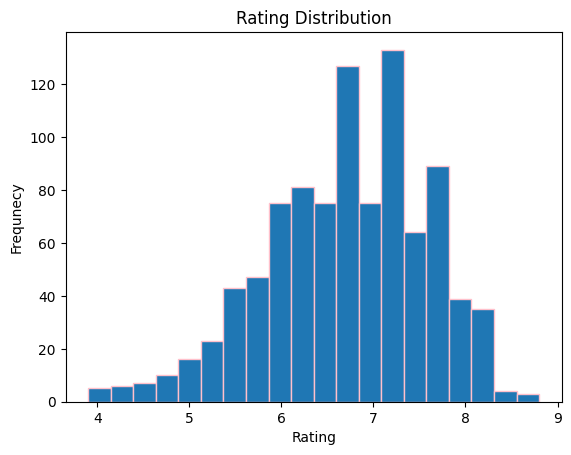

In [29]:
plt.hist(df["Rating"] , bins = 20, edgecolor = "pink")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequnecy")
plt.show()

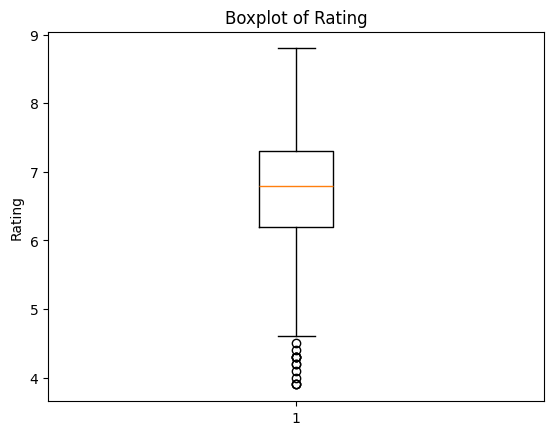

In [30]:
plt.boxplot(df["Rating"])
plt.title("Boxplot of Rating")
plt.ylabel("Rating")
plt.show()

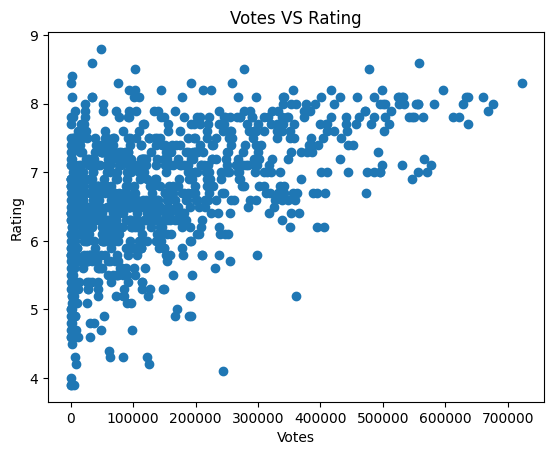

In [31]:
plt.scatter(df["Votes"],df["Rating"])
plt.title("Votes VS Rating")
plt.xlabel("Votes")
plt.ylabel("Rating")
plt.show()

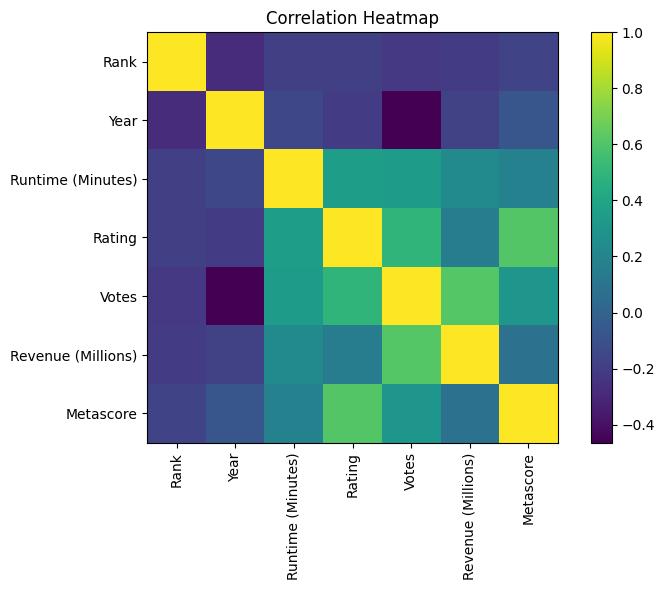

In [33]:
corr = df[num_cols].corr()

plt.figure(figsize = (8 , 6))
plt.imshow(corr , cmap = "viridis")
plt.xticks(range(len(num_cols)) , num_cols , rotation = 90)
plt.yticks(range(len(num_cols)) , num_cols)
plt.title("Correlation Heatmap")
plt.colorbar()
plt.tight_layout()
plt.show()